In [1]:
#import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
#load data
NOAA_SFO_df = pd.read_parquet(
    "../Data_Preprocessing/data/NOAA_SFO_2022_2026_cleaned.parquet"
)

NOAA_SFO_df.head()

,STATION,Station_name,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,...,precipitation_6_hour_Source_Station_ID,precipitation_24_hour,precipitation_24_hour_Quality_Code,precipitation_24_hour_Report_Type,precipitation_24_hour_Source_Code,precipitation_24_hour_Source_Station_ID,REM,REM_Report_Type,REM_Source_Code,REM_Source_Station_ID
0,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,SYN08072494 32566 42915 10117 20044 30094 4012...,FM12,223,ICAO-KSFO
1,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09812/31/21 16:56:03 METAR KSFO 010056Z 300...,FM15,343,724940-23234
2,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09812/31/21 17:56:03 METAR KSFO 010156Z 300...,FM15,343,724940-23234
3,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10112/31/21 18:56:03 METAR KSFO 010256Z 290...,FM15,343,724940-23234
4,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09812/31/21 19:56:03 METAR KSFO 010356Z 310...,FM15,343,724940-23234


**Split training and test data for EDA purposes**
60/20/20 training/test/validation split. it is crucial we do not perform EDA on test and validation dataset

In [3]:
#First split:
# train = oldest 60%
# temp = most recent 40%
NOAA_train_df, NOAA_temp_df = train_test_split(
    NOAA_SFO_df,
    test_size=0.40,
    shuffle=False
)

# Second split:
# test = older half of temp, so subsequent 20%
# validation = newer half of temp, so most recent 20%
NOAA_test_df, NOAA_val_df = train_test_split(
    NOAA_temp_df,
    test_size=0.50,
    shuffle=False
)

# Check shapes
print(f"Training shape: {NOAA_train_df.shape}")
print(f"Test shape: {NOAA_test_df.shape}")
print(f"Validation shape: {NOAA_val_df.shape}")

Training shape: (53505, 220)
Test shape: (17835, 220)
Validation shape: (17836, 220)


In [4]:
#Verify split by confirming date 

print("Training date range:")
print(NOAA_train_df["DATE"].min(), "to", NOAA_train_df["DATE"].max())

print("\nTest date range:")
print(NOAA_test_df["DATE"].min(), "to", NOAA_test_df["DATE"].max())

print("\nValidation date range:")
print(NOAA_val_df["DATE"].min(), "to", NOAA_val_df["DATE"].max())

Training date range:
2022-01-01 00:00:00 to 2026-01-20 00:55:00

Test date range:
2026-01-20 00:56:00 to 2026-03-31 19:40:00

Validation date range:
2026-03-31 19:45:00 to 2026-06-09 16:56:00


**Perform EDA**

Describe float features

In [5]:
feature_cols = [
    "LATITUDE",
    "LONGITUDE",
    "ELEVATION",
    "temperature",
    "dew_point_temperature",
    "wind_direction",
    "wind_speed",
    "wind_gust",
    "precipitation",
    "relative_humidity",
    "visibility",
    "sea_level_pressure",
    "station_level_pressure",
    "ceiling_height",
    "altimeter"
]

feature_cols = [col for col in feature_cols if col in NOAA_train_df.columns]

display(NOAA_train_df[feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
LATITUDE,53505.0,37.619700,2.860672e-11,37.6197,37.6197,37.6197,37.6197,37.6197
LONGITUDE,53505.0,-122.365600,7.872887e-11,-122.3656,-122.3656,-122.3656,-122.3656,-122.3656
ELEVATION,53505.0,3.000000,0.000000e+00,3.0000,3.0000,3.0000,3.0000,3.0000
temperature,49534.0,14.331871,3.841660e+00,2.2000,11.7000,13.9000,16.7000,36.7000
dew_point_temperature,49534.0,9.589363,3.429395e+00,-8.9000,7.8000,10.0000,12.2000,20.0000
wind_direction,49529.0,312.174019,2.435242e+02,10.0000,210.0000,280.0000,300.0000,999.0000
wind_speed,49529.0,4.672166,3.113462e+00,0.0000,2.1000,4.1000,6.7000,22.1000
wind_gust,5653.0,13.407890,3.303617e+00,7.2000,11.3000,12.9000,14.9000,37.1000
precipitation,32772.0,0.090126,5.813448e-01,0.0000,0.0000,0.0000,0.0000,22.3000
relative_humidity,49534.0,74.984233,1.415377e+01,10.0000,67.0000,77.0000,86.0000,100.0000


Distribution of float features

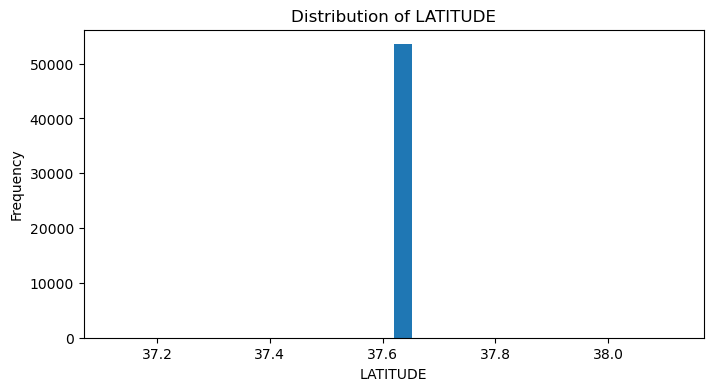

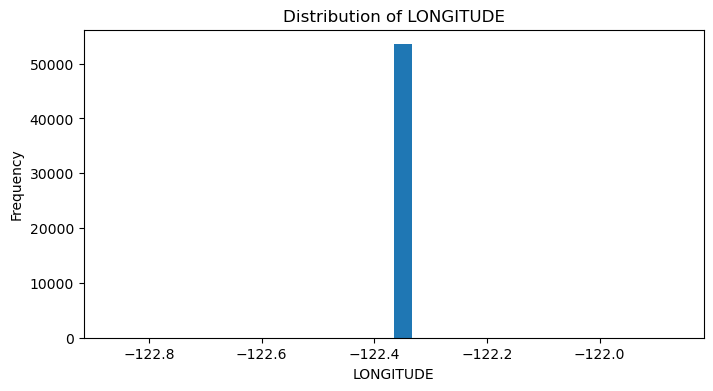

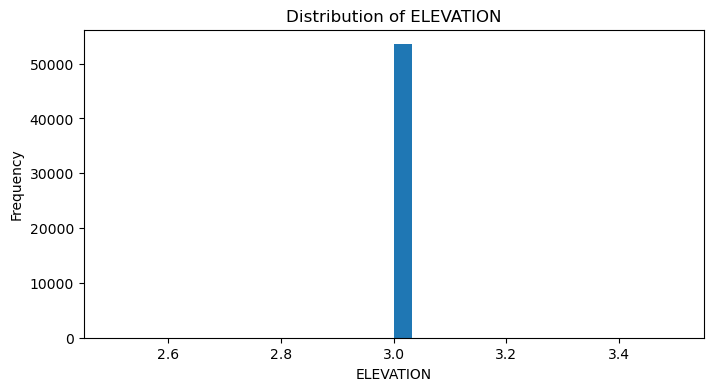

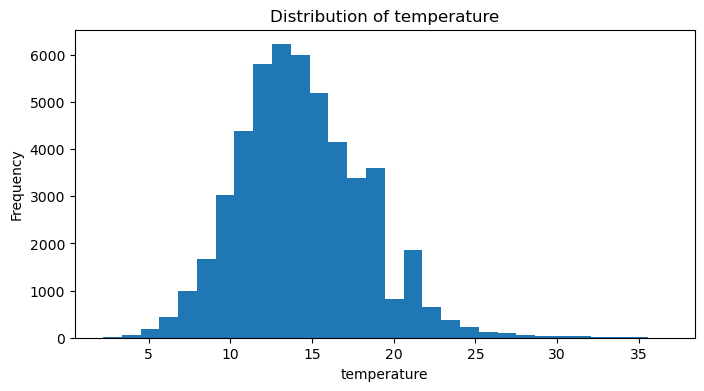

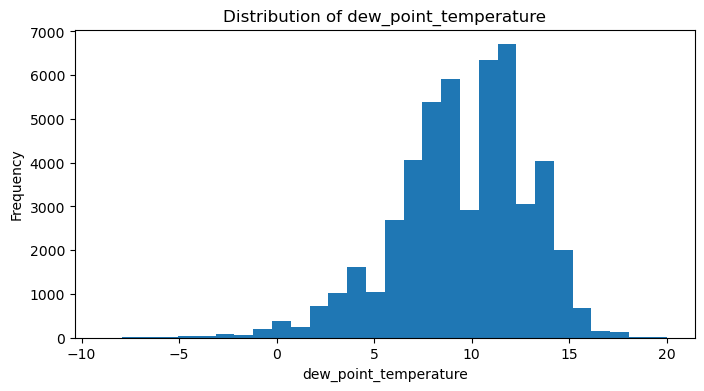

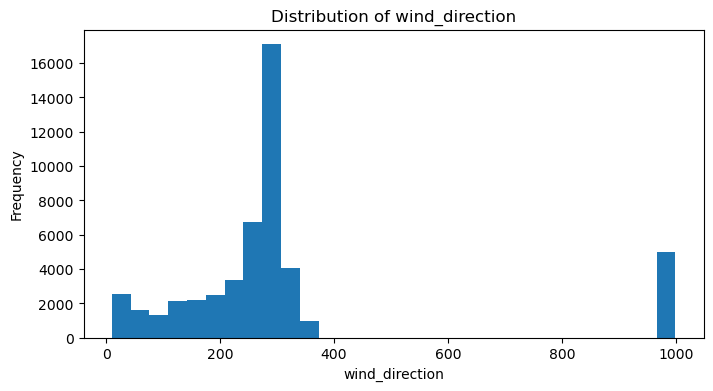

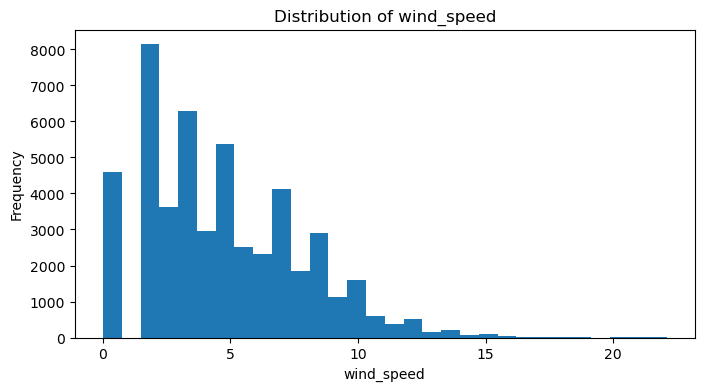

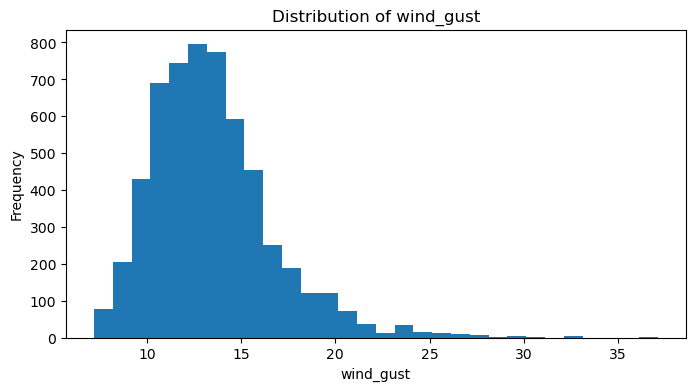

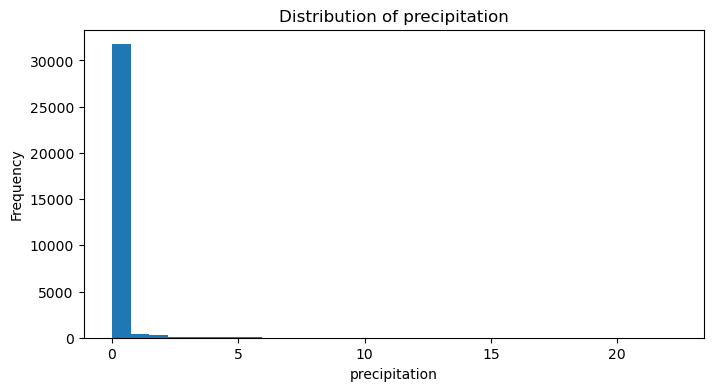

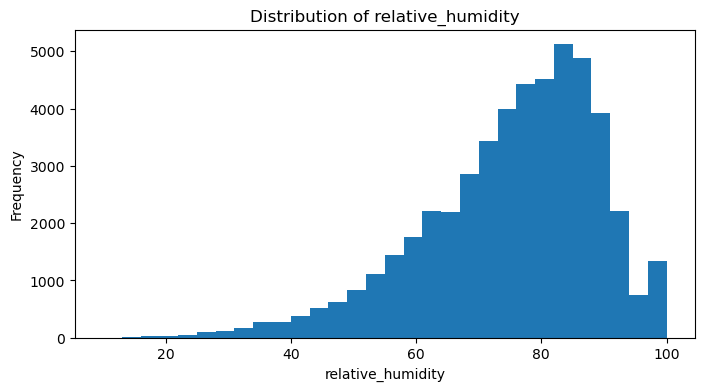

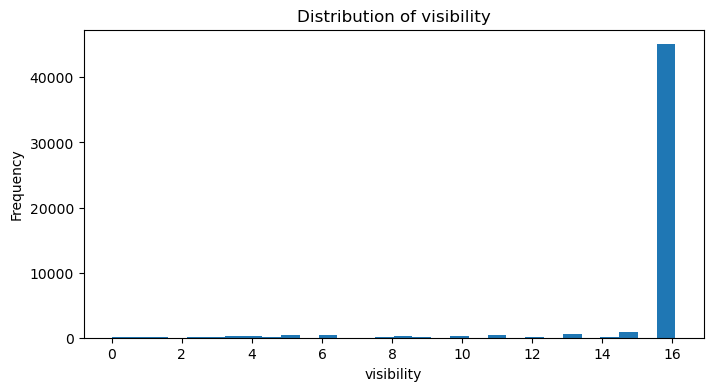

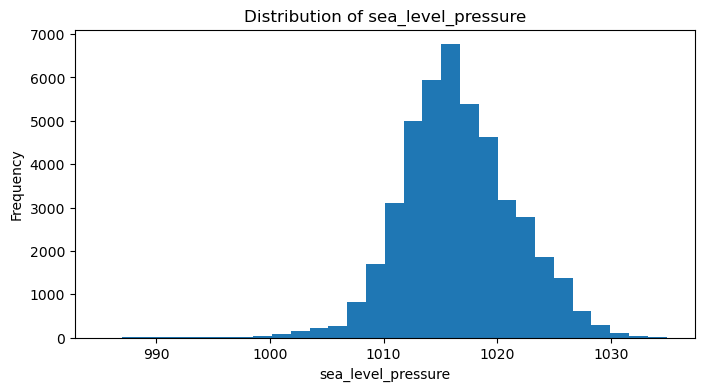

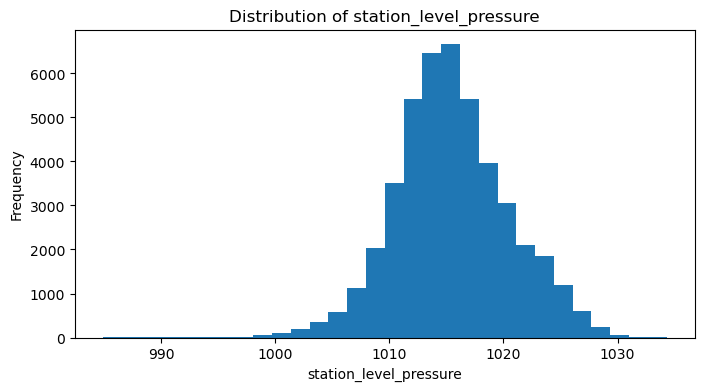

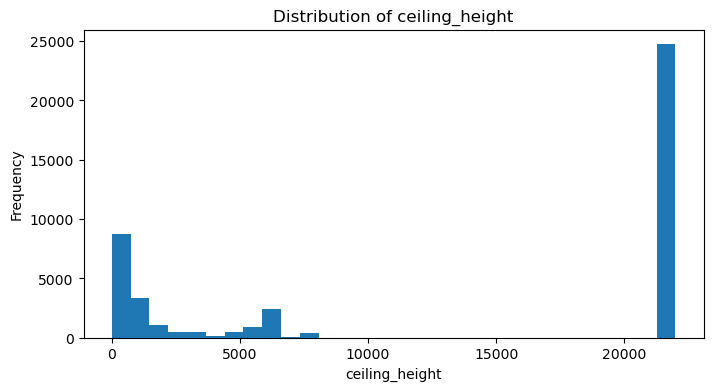

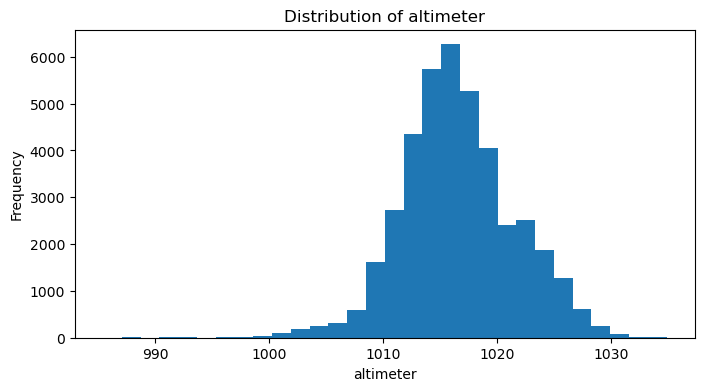

In [6]:
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(NOAA_train_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

Monthly trends

In [7]:
#Distribution plots of weather information

#create monthly trends
monthly_trend = [
    "temperature",
    "wind_speed",
    "visibility",
    "precipitation",
    "relative_humidity",
    "sea_level_pressure",
    "station_level_pressure",
    "altimeter"

]

# Create month/year bin
NOAA_train_df["Month_Year"] = NOAA_train_df["DATE"].dt.to_period("M")

# Calculate monthly average temperature
monthly_weather = NOAA_train_df.groupby("Month_Year")[monthly_trend].mean().reset_index()

# Convert Month_Year back to timestamp for plotting
monthly_weather["Month_Year"] = monthly_weather["Month_Year"].dt.to_timestamp()

Temperature Distribution


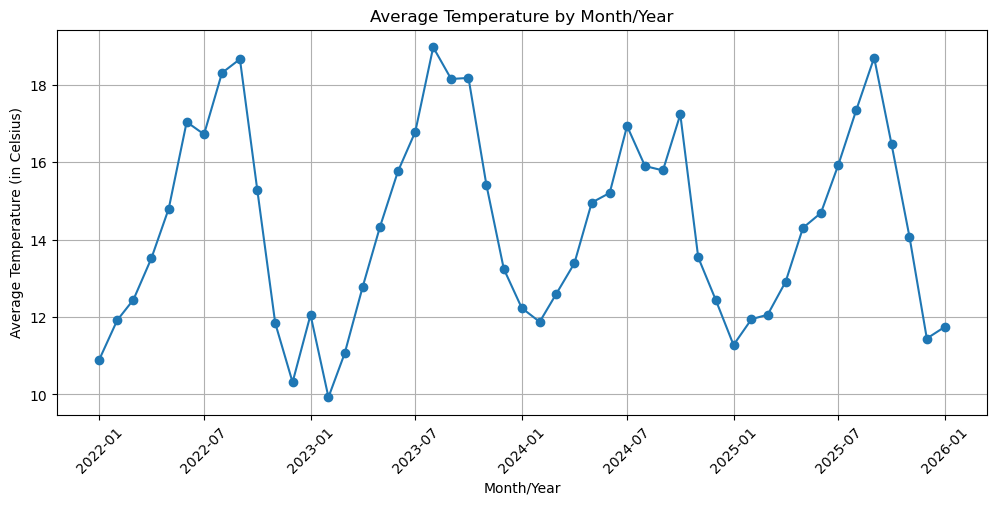

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["temperature"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average Temperature (in Celsius)")
plt.title("Average Temperature by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Wind speed monthly

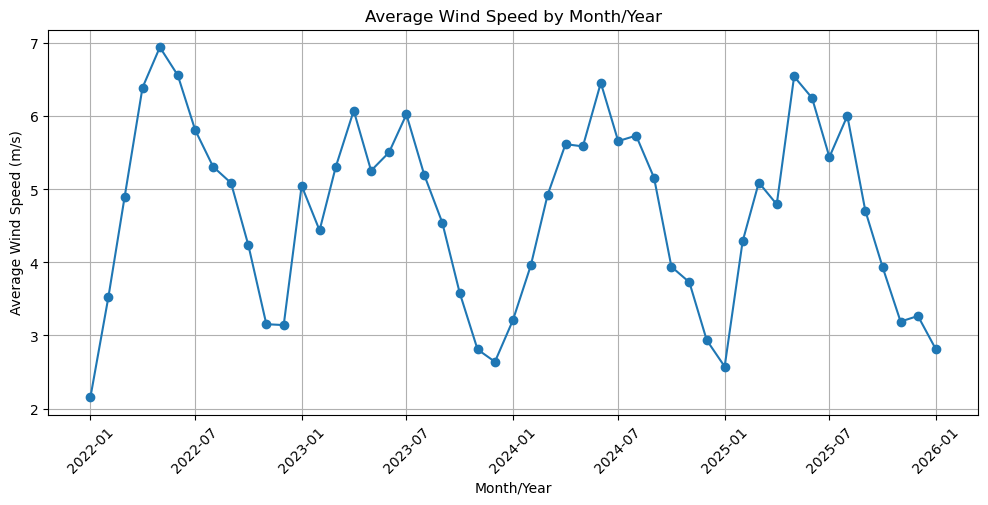

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["wind_speed"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average Wind Speed (m/s)")
plt.title("Average Wind Speed by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Monthly visibility

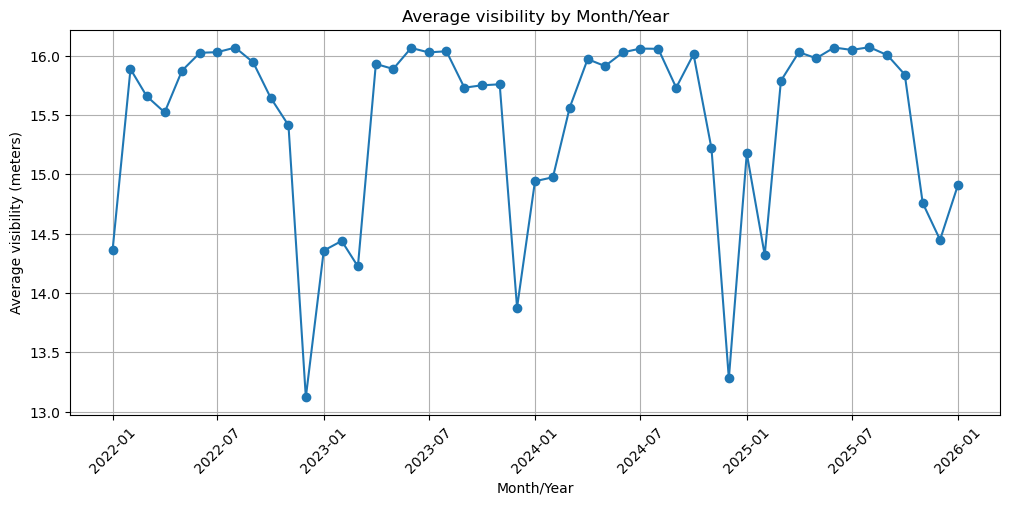

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["visibility"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average visibility (meters)")
plt.title("Average visibility by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Monthly precipitation

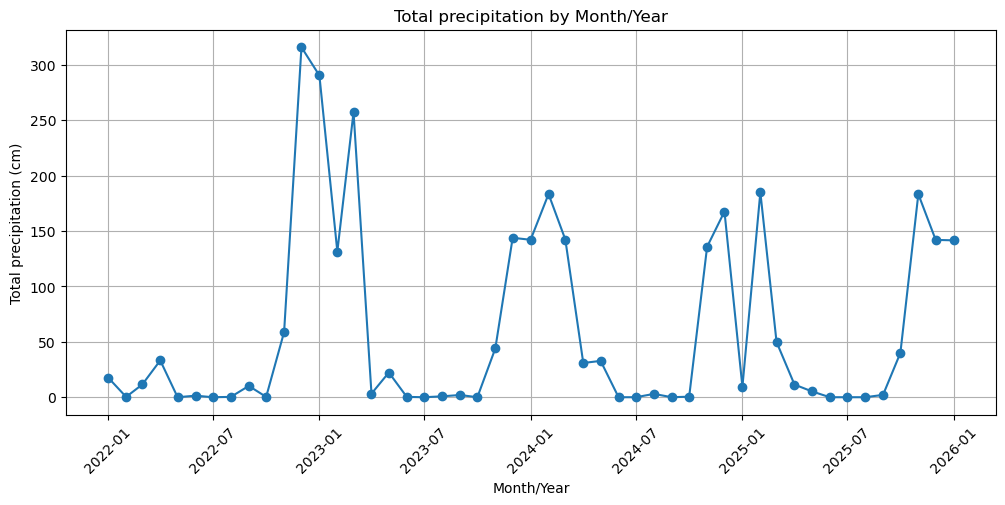

In [11]:
# we should probably do total precipitation here

monthly_precip = NOAA_train_df.groupby("Month_Year")["precipitation"].sum().reset_index()
monthly_precip["Month_Year"] = monthly_precip["Month_Year"].dt.to_timestamp()


plt.figure(figsize=(12, 5))
plt.plot(monthly_precip["Month_Year"], monthly_precip["precipitation"],marker="o")
plt.xlabel("Month/Year")
plt.ylabel("Total precipitation (cm)")
plt.title("Total precipitation by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Monthly Relative Humidity

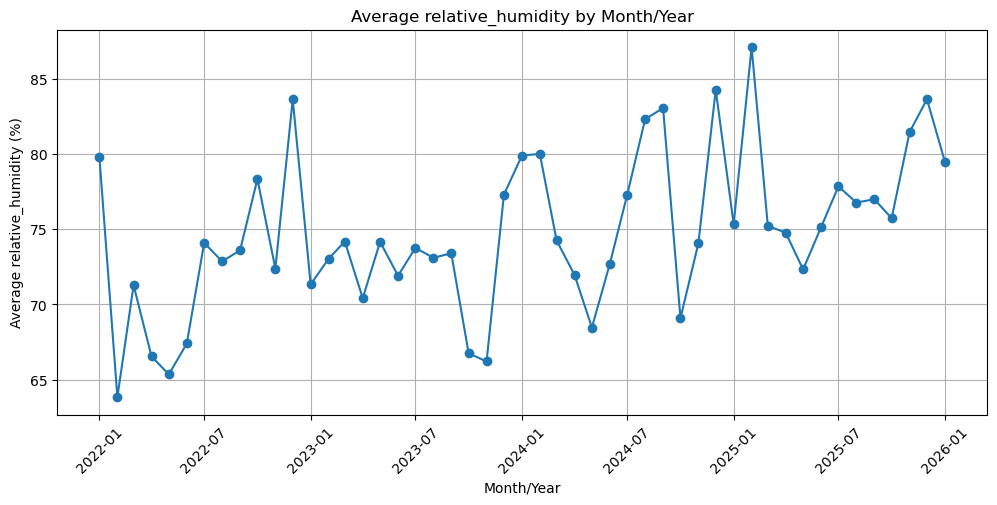

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["relative_humidity"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average relative_humidity (%)")
plt.title("Average relative_humidity by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Correlation Matrix**

In [13]:
corr = NOAA_train_df[feature_cols].corr()

display(corr)

,LATITUDE,LONGITUDE,ELEVATION,temperature,dew_point_temperature,wind_direction,wind_speed,wind_gust,precipitation,relative_humidity,visibility,sea_level_pressure,station_level_pressure,ceiling_height,altimeter
LATITUDE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LONGITUDE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ELEVATION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,NaN,NaN,NaN,1.000000,0.574337,-0.084186,0.288262,-0.088422,-0.073216,-0.521804,0.142663,-0.358065,-0.320829,0.129350,-0.332840
dew_point_temperature,NaN,NaN,NaN,0.574337,1.000000,-0.094383,0.108710,-0.114028,0.056689,0.382115,-0.078000,-0.414503,-0.384168,-0.158418,-0.393163
wind_direction,NaN,NaN,NaN,-0.084186,-0.094383,1.000000,-0.351456,-0.069325,-0.057210,0.007701,0.023209,0.116334,0.124351,0.084090,0.126769
wind_speed,NaN,NaN,NaN,0.288262,0.108710,-0.351456,1.000000,0.898240,0.079708,-0.233939,0.008372,-0.317914,-0.309215,0.032877,-0.324584
wind_gust,NaN,NaN,NaN,-0.088422,-0.114028,-0.069325,0.898240,1.000000,0.171945,-0.033087,-0.205385,-0.210605,-0.263921,0.067733,-0.267205
precipitation,NaN,NaN,NaN,-0.073216,0.056689,-0.057210,0.079708,0.171945,1.000000,0.159384,-0.460414,-0.183448,-0.203124,-0.197371,-0.207384
relative_humidity,NaN,NaN,NaN,-0.521804,0.382115,0.007701,-0.233939,-0.033087,0.159384,1.000000,-0.281797,-0.028864,-0.038419,-0.323212,-0.033525


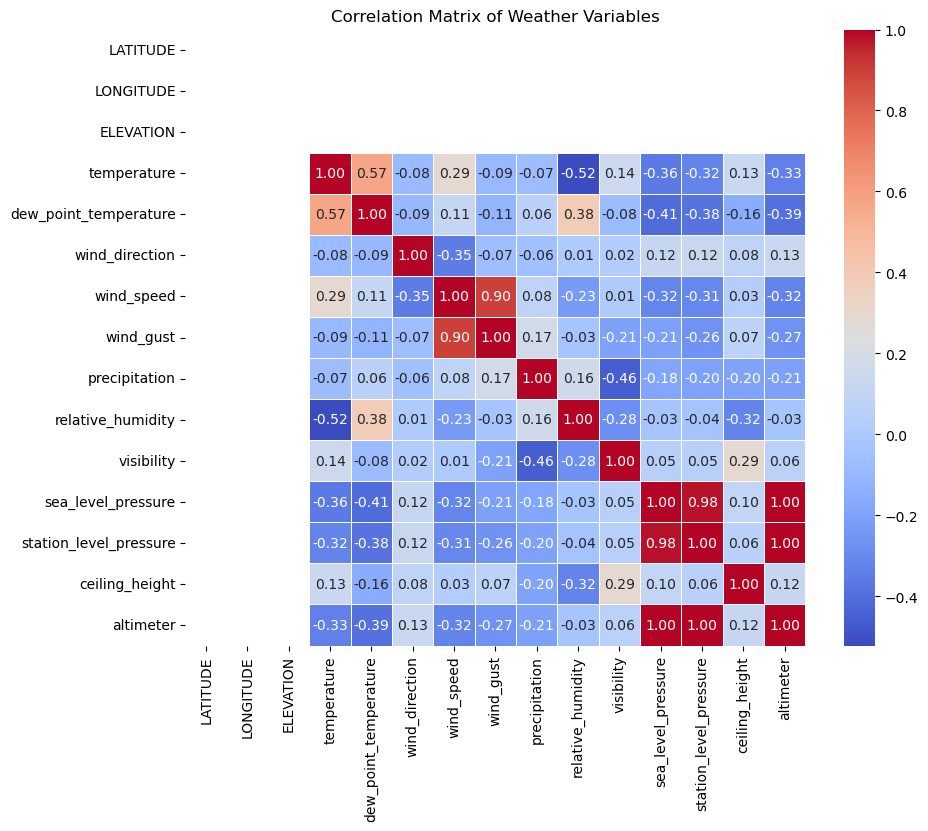

In [15]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Weather Variables")
plt.show()